# Python Basics

**Duration** ~90 min &nbsp;·&nbsp; **Session** Day 0, at home

This short introduction covers the Python you will use in the image analysis
notebooks. If you already know Python, skim the examples and use the recap to
check which topics are familiar.

**Data**: none. The examples use small arrays and tables, so you can work through
them before downloading the course data.

**How to use it**: run each code cell, then change a value and run it again. If a
result surprises you, check the code and the output before moving on.

## 1. How a notebook works

A notebook is a list of **cells**. This one is a text cell. The one below is a
code cell.

Click the code cell and press **Shift+Enter** to run it.

In [1]:
2 + 2

4

The result appears underneath. A cell shows you the value of its **last line**
automatically, which is handy, but only works for the last line.

In [2]:
2 + 2
3 + 3

6

Only `6` appeared. If you want to see more than one thing, ask for it with
`print`.

In [3]:
print(2 + 2)
print(3 + 3)

4
6


```{tip}
Cells share their memory, and they run in **the order you run them**, not the
order they appear on the page. If something behaves strangely, the usual cause is
cells run out of order: fix it with *Kernel ▸ Restart and Run All*.
```

## 2. Variables

A variable is a name for a value. `=` means *"give this name to this value"*, not
"is equal to".

In [4]:
diameter = 12
name = "nucleus"
is_bright = True

print(diameter)
print(name)
print(is_bright)

12
nucleus
True


Three kinds of value there, and Python tracks the difference:

| type | what it is | examples |
|---|---|---|
| `int` | whole number | `12`, `0`, `-3` |
| `float` | number with a decimal point | `12.5`, `0.02` |
| `str` | text, in quotes | `"nucleus"` |
| `bool` | true or false | `True`, `False` |

`type()` tells you which one you have. You will use this more than you expect,
usually when something is not behaving.

In [5]:
print(type(diameter))
print(type(12.5))
print(type(name))
print(type(is_bright))

<class 'int'>
<class 'float'>
<class 'str'>
<class 'bool'>


Names can be reused, and the value can change:

In [6]:
count = 10
count = count + 5      # take the old value, add 5, store it back
print(count)

count += 1             # shorthand for exactly the same thing
print(count)

15
16


## 3. Showing values: f-strings

You will print numbers constantly: object counts, thresholds, measurements. The
comfortable way is an **f-string**: an `f` before the quotes, and any expression
in `{curly braces}` gets replaced by its value.

In [7]:
count = 34
truth = 39

print(f"found {count} objects")
print(f"the annotation says {truth}")
print(f"we are {truth - count} short")

found 34 objects
the annotation says 39
we are 5 short


You can control how numbers are shown by adding `:` and a format after the
expression. This matters when a raw float prints as `0.6842105263157895`.

In [8]:
fraction = count / truth

print(f"plain      : {fraction}")
print(f"2 decimals : {fraction:.2f}")
print(f"percentage : {fraction:.1%}")
print(f"padded     : {count:5d} objects")

plain      : 0.8717948717948718
2 decimals : 0.87
percentage : 87.2%
padded     :    34 objects


| format | means | example output |
|---|---|---|
| `:.2f` | 2 decimal places | `0.87` |
| `:.1%` | as a percentage | `87.2%` |
| `:5d` | whole number, padded to 5 characters | `&nbsp;&nbsp;&nbsp;34` |

The padding one is what lines numbers up into neat columns in the course
notebooks.

## 4. Lists and tuples

A **list** holds several values in order. Square brackets, commas between.

In [9]:
areas = [236, 512, 480, 1305, 390]

print(areas)
print(f"{len(areas)} values")
print(f"first : {areas[0]}")
print(f"third : {areas[2]}")
print(f"last  : {areas[-1]}")

[236, 512, 480, 1305, 390]
5 values
first : 236
third : 480
last  : 390


**Counting starts at zero.** `areas[0]` is the first item. This is the single most
common source of off-by-one confusion, and `[-1]` for "the last one" is worth
memorising.

You can take a **slice**, a range of items, with `start:stop`. The stop is *not*
included.

In [10]:
print(areas[0:3])    # items 0, 1, 2  -  not 3
print(areas[:3])     # same thing, from the beginning
print(areas[2:])     # from item 2 to the end

[236, 512, 480]
[236, 512, 480]
[480, 1305, 390]


Lists can be changed after they are made:

In [11]:
areas.append(875)          # add one to the end
print(areas)
print(f"largest: {max(areas)}, smallest: {min(areas)}, total: {sum(areas)}")

[236, 512, 480, 1305, 390, 875]
largest: 1305, smallest: 236, total: 3798


A **tuple** is the same idea with round brackets, and cannot be changed
afterwards. You mostly meet tuples as *the shape of an image*.

In [12]:
shape = (348, 512)
print(shape)
print(f"{shape[0]} rows, {shape[1]} columns")

(348, 512)
348 rows, 512 columns


### Unpacking

If you know how many items there are, you can name them all at once. This is
everywhere in the course notebooks.

In [13]:
rows, columns = shape          # instead of shape[0] and shape[1]
print(f"{rows} x {columns}")

# It works for any matching number of names and values.
low, high = 0, 255
print(f"values run from {low} to {high}")

348 x 512
values run from 0 to 255


## 5. Dictionaries

A **dictionary** stores values under names rather than positions. Curly braces,
`name: value` pairs.

In [14]:
measurement = {"area": 512, "intensity": 88.4, "label": "nucleus 7"}

print(measurement["area"])
print(measurement["label"])

measurement["perimeter"] = 91.2      # add a new entry
print(measurement)

512
nucleus 7
{'area': 512, 'intensity': 88.4, 'label': 'nucleus 7', 'perimeter': 91.2}


Use a dictionary when the things have names, and a list when they have an order.
In the course you will mostly meet dictionaries as a way to keep several results
side by side:

```python
results = {"threshold": threshold_labels, "Cellpose": cellpose_labels}
```

## 6. Doing something to everything: loops

In [15]:
areas = [236, 512, 480, 1305, 390]

for area in areas:
    print(f"this object covers {area} pixels")

this object covers 236 pixels
this object covers 512 pixels
this object covers 480 pixels
this object covers 1305 pixels
this object covers 390 pixels


Read it as *"for each item in `areas`, call it `area`, and do the indented
part"*.

**The indentation is the syntax.** Python has no braces or `end` keyword; the
indented lines are the body of the loop, and the first unindented line is after
it. Four spaces is the convention, and Jupyter inserts them for you when you
press Tab.

In [16]:
big = 0

for area in areas:
    if area > 450:
        big += 1              # this line is inside BOTH the loop and the if

print(f"{big} objects are larger than 450 px")

3 objects are larger than 450 px


Two loop helpers you will see constantly:

- **`enumerate`** gives you the position as well as the item;
- **`zip`** walks two lists side by side.

In [17]:
for position, area in enumerate(areas):
    print(f"object {position}: {area} px")

object 0: 236 px
object 1: 512 px
object 2: 480 px
object 3: 1305 px
object 4: 390 px


In [18]:
names = ["nucleus", "nucleus", "debris", "clump", "nucleus"]

for name, area in zip(names, areas):
    print(f"{name:8s} {area:5d} px")

nucleus    236 px
nucleus    512 px
debris     480 px
clump     1305 px
nucleus    390 px


## 7. Making decisions

In [19]:
threshold = 450

for area in areas:
    if area < 100:
        verdict = "too small - probably noise"
    elif area > 1000:
        verdict = "too big - probably two objects merged"
    else:
        verdict = "plausible"
    print(f"{area:5d} px  ->  {verdict}")

  236 px  ->  plausible
  512 px  ->  plausible
  480 px  ->  plausible
 1305 px  ->  too big - probably two objects merged
  390 px  ->  plausible


`if` … `elif` … `else`. Only the **first** matching branch runs.

The comparisons available are the ones you would expect: `<`, `>`, `<=`, `>=`,
`==` for "is equal to", and `!=` for "is not equal to". Note the double equals: 
a single `=` assigns, and writing `if area = 450` is an error rather than a
comparison.

## 8. Functions

A function is a named piece of code you can run again with different inputs.
Define it once with `def`, then call it as often as you like.

In [20]:
def describe(area):
    """Say whether an object's area is plausible for a nucleus."""
    if area < 100:
        return "too small"
    if area > 1000:
        return "too big"
    return "plausible"


print(describe(45))
print(describe(512))
print(describe(1305))

too small
plausible
too big


- everything indented under `def` is the function's body;
- `return` hands a value back to whoever called it, and stops the function;
- the text in triple quotes is a **docstring**: a note to your future self.

### Arguments with defaults

A function can have arguments with a default value, which you may leave out.

In [21]:
def describe(area, smallest=100, largest=1000):
    if area < smallest:
        return "too small"
    if area > largest:
        return "too big"
    return "plausible"


print(describe(45))                  # uses the defaults
print(describe(45, smallest=20))     # overrides one of them

too small
plausible


Naming the argument when you call it, `smallest=20`, is a **keyword argument**.
The library functions in this course have a lot of these, and naming them makes
the call readable:

```python
gaussian(image, sigma=2, preserve_range=True)
```

You would have no idea what `gaussian(image, 2, True)` meant six months later.

## 9. Using other people's code

Most image analysis functions we use come from Python libraries. You **import** them before calling them.

In [22]:
import numpy as np              # the whole library, under a short nickname
from skimage.filters import threshold_otsu   # one specific function

print(np.sqrt(16))

4.0


Two forms:

- `import numpy as np`: everything, reached as `np.something`. The `as np` is a
  universal convention; do not invent your own.
- `from x import y`: pull one name out, so you can write `y(...)` directly.

Put your imports in the first code cell of a notebook, so a reader can see the
dependencies at a glance.

## 10. NumPy arrays

**An image is a NumPy array**: a grid of numbers. Image operations generally work on those arrays.

In [23]:
import numpy as np

# A tiny 4x5 "image", made by hand.
image = np.array([
    [10, 12, 11, 10, 13],
    [11, 90, 95, 12, 11],
    [10, 92, 98, 11, 12],
    [12, 11, 10, 13, 11],
])

print(image)

[[10 12 11 10 13]
 [11 90 95 12 11]
 [10 92 98 11 12]
 [12 11 10 13 11]]


In [24]:
print("shape:", image.shape)      # (rows, columns)
print("dtype:", image.dtype)      # what kind of number
print("size :", image.size)       # how many values in total

shape: (4, 5)
dtype: int64
size : 20


`shape` is `(rows, columns)`: **height first**. Nearly everyone gets this the
wrong way round at least once.

Useful ways to make an array without typing it out:

In [25]:
print(np.zeros((2, 3)))            # filled with 0
print()
print(np.arange(0, 10, 2))         # 0 up to (not including) 10, in steps of 2
print()
print(np.linspace(0, 1, 5))        # 5 values evenly spaced from 0 to 1

[[0. 0. 0.]
 [0. 0. 0.]]

[0 2 4 6 8]

[0.   0.25 0.5  0.75 1.  ]


## 11. Indexing and slicing an array

Same rules as lists, but with a row and a column.

In [26]:
print("one pixel      :", image[1, 2])      # row 1, column 2
print("a whole row    :", image[1])
print("a whole column :", image[:, 2])      # ':' means 'all of them'

one pixel      : 95
a whole row    : [11 90 95 12 11]
a whole column : [11 95 98 10]


In [27]:
# A rectangle: rows 1 to 2, columns 1 to 2. This is cropping.
crop = image[1:3, 1:3]
print(crop)
print("shape:", crop.shape)

[[90 95]
 [92 98]]
shape: (2, 2)


## 12. Asking a question of every pixel at once

This is the idea that makes array code short, and it is worth slowing down for.

Compare the whole array to a number, and you get back **an array of `True` and
`False`**: one answer per pixel. No loop needed.

In [28]:
bright = image > 50
print(bright)

[[False False False False False]
 [False  True  True False False]
 [False  True  True False False]
 [False False False False False]]


An image with only two values like this is called a **binary image**, and it is
exactly what thresholding produces. When you use one to *select* pixels from
another image, as below, it is usually called a **mask**: same array, different
role.

Because `True` counts as 1 and `False` as 0, you can immediately ask how many
pixels passed:

In [29]:
print("bright pixels    :", bright.sum())
print("fraction bright  :", bright.mean())
print(f"as a percentage : {bright.mean():.1%}")

bright pixels    : 4
fraction bright  : 0.2
as a percentage : 20.0%


You can also use a mask to pull out just those values, or to change them:

In [30]:
print("the bright values:", image[bright])
print("their average    :", image[bright].mean())

copy = image.copy()          # work on a copy, not the original
copy[bright] = 0             # set every bright pixel to zero
print(copy)

the bright values: [90 95 92 98]
their average    : 93.75
[[10 12 11 10 13]
 [11  0  0 12 11]
 [10  0  0 11 12]
 [12 11 10 13 11]]


```{warning}
`copy = image` does **not** make a copy: it gives the same array a second name,
and changing one changes the other. Use `.copy()` when you mean a copy.
```

## 13. Summarising an array

In [31]:
print(f"smallest : {image.min()}")
print(f"largest  : {image.max()}")
print(f"average  : {image.mean():.1f}")
print(f"total    : {image.sum()}")
print(f"spread   : {image.std():.1f}")

smallest : 10
largest  : 98
average  : 27.8
total    : 555
spread   : 33.0


These are **methods**: functions that belong to the array, called with a dot
after it. You will use `.max()` more than any other, usually to ask how many
objects a label image contains.

## 14. Plotting

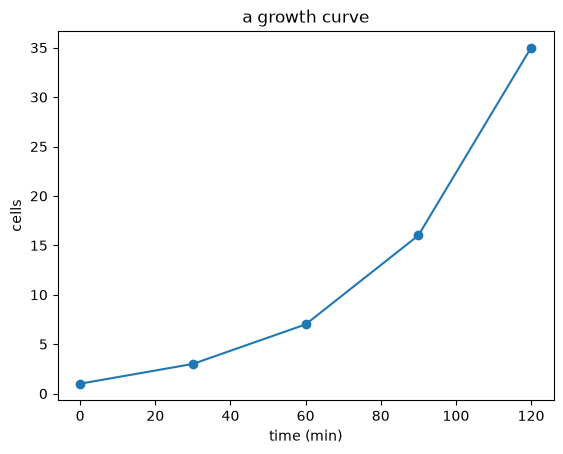

In [32]:
import matplotlib.pyplot as plt

plt.plot([0, 30, 60, 90, 120], [1, 3, 7, 16, 35], "o-")
plt.xlabel("time (min)")
plt.ylabel("cells")
plt.title("a growth curve")
plt.show()

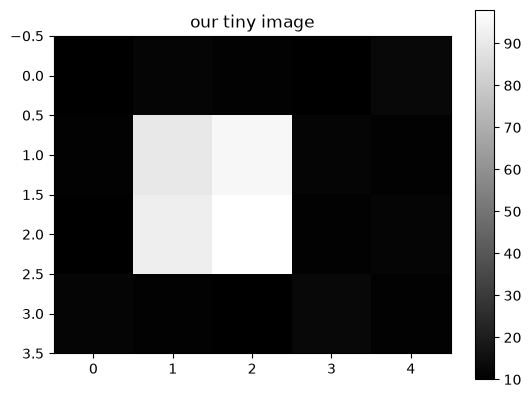

In [33]:
# An array can be drawn as an image.
plt.imshow(image, cmap="gray")
plt.colorbar()
plt.title("our tiny image")
plt.show()

### Several panels side by side

`plt.subplots` makes a figure with several panels. It hands back **two** things: 
the figure and the panels, which is why you see that tuple unpacking from
section 4 again.

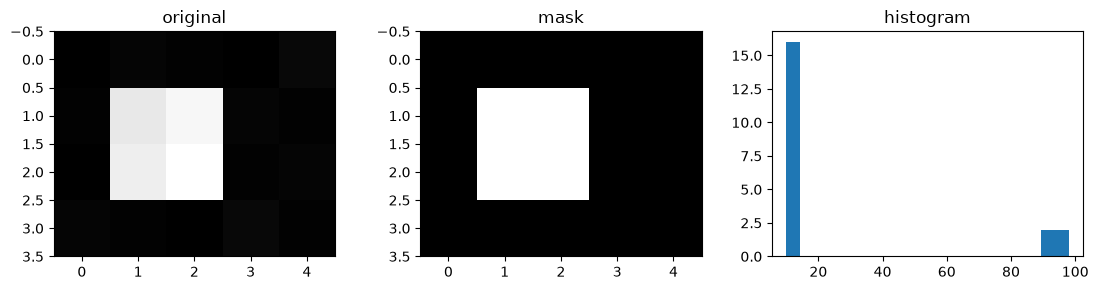

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(11, 3))

axes[0].imshow(image, cmap="gray")
axes[0].set_title("original")

axes[1].imshow(image > 50, cmap="gray")
axes[1].set_title("mask")

axes[2].hist(image.ravel(), bins=20)
axes[2].set_title("histogram")

plt.tight_layout()
plt.show()

`axes` is a list of panels, so `axes[0]` is the first. `.ravel()` flattens the 2D
image into a plain list of values, which is what a histogram needs.

A pattern you will see often is `zip` from section 6, used to pair panels with
things to draw in them:

```python
for ax, title in zip(axes, ["original", "mask", "histogram"]):
    ...
```

## 15. File paths

In [35]:
from pathlib import Path

folder = Path("data") / "bbbc020" / "images"
filename = folder / "2h_1_nuclei.tif"

print(filename)
print("name only:", filename.name)
print("does it exist here?", filename.exists())

data/bbbc020/images/2h_1_nuclei.tif
name only: 2h_1_nuclei.tif
does it exist here? False


The `/` between path pieces reads oddly at first, but it builds the right kind of
path on every operating system: no worrying about `/` versus `\`.

In the course notebooks `DATA` is already defined for you, so you will write
`DATA / "bbbc020" / "images" / "2h_1_nuclei.tif"`.

## 16. Tables

Once you have measured objects you will have a table, and `pandas` is the tool
for those. You only need a little of it.

In [36]:
import pandas as pd

table = pd.DataFrame({
    "area": [236, 512, 480, 1305, 390, 875],
    "roundness": [0.91, 0.88, 0.95, 0.42, 0.89, 0.55],
    "kind": ["nucleus", "nucleus", "nucleus", "clump", "nucleus", "clump"],
})

table

,area,roundness,kind
0,236,0.91,nucleus
1,512,0.88,nucleus
2,480,0.95,nucleus
3,1305,0.42,clump
4,390,0.89,nucleus
5,875,0.55,clump


In [37]:
print(table["area"])            # one column
print()
print(table.shape)              # (rows, columns)
print()
print(table["area"].mean())     # columns behave like arrays

0     236
1     512
2     480
3    1305
4     390
5     875
Name: area, dtype: int64

(6, 3)

633.0


Filtering uses the same mask idea as section 12: a condition on a column gives
`True`/`False` per row, and the table keeps the `True` ones.

In [38]:
big = table[table["area"] > 450]
print(big)

   area  roundness     kind
1   512       0.88  nucleus
2   480       0.95  nucleus
3  1305       0.42    clump
5   875       0.55    clump


In [39]:
# Split into groups and summarise each one.
print(table.groupby("kind")["area"].median())

kind
clump      1090.0
nucleus     435.0
Name: area, dtype: float64


For this course, you will mainly use pandas to make tables, select columns and rows, and summarise groups.

## Recap

Check that you can read these examples. Return to the relevant section if one is unfamiliar.

```python
count = 34                              # a variable
print(f"found {count} objects")         # an f-string
print(f"{fraction:.1%}")                # formatted to 1 decimal, as a percentage

areas = [236, 512, 480]                 # a list
areas[0], areas[-1]                     # first and last
rows, columns = image.shape             # unpacking a tuple

for area in areas:                      # a loop
    if area > 450:                       # a decision - note the indentation
        print(area)

for i, area in enumerate(areas): ...     # position as well as item
for name, area in zip(names, areas): ... # two lists side by side

def describe(area, smallest=100):        # a function with a default
    return "too small" if area < smallest else "fine"

import numpy as np                       # a library, nicknamed
from skimage.filters import threshold_otsu

image.shape, image.dtype                 # (rows, columns) and the number type
image[1, 2]                              # one pixel
image[1:3, 1:3]                          # a crop
mask = image > 50                        # a question asked of every pixel
mask.sum(), mask.mean()                  # how many, what fraction
image[mask].mean()                       # average of just those pixels
labels.max()                             # how many objects

fig, axes = plt.subplots(1, 3)           # several panels
axes[0].imshow(image, cmap="gray")

DATA / "bbbc020" / "images" / "x.tif"    # a file path

table["area"].mean()                     # a column
table[table["area"] > 450]               # filtered rows
table.groupby("kind")["area"].median()   # grouped summary
```

Next, try `00_python_basics_ex` to practise these steps.